In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.patches import Rectangle

import textwrap


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


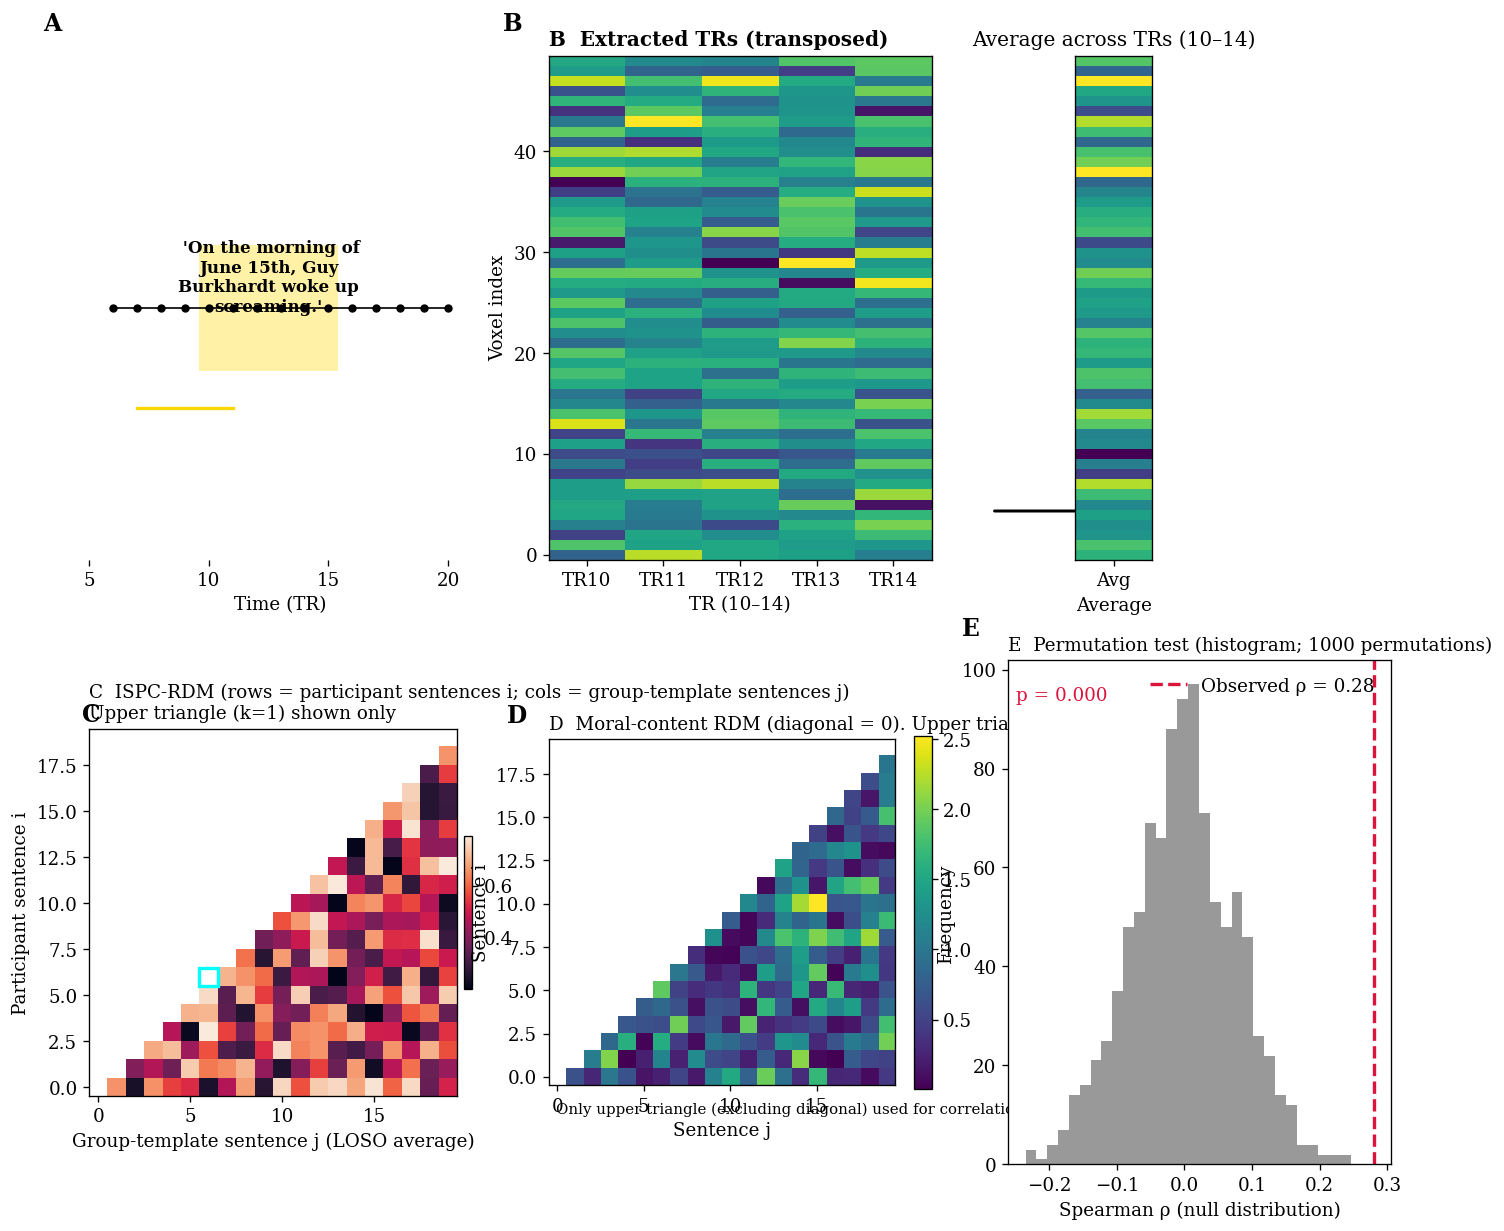

In [5]:
fig = plt.figure(figsize=(14, 12))
# -------------------------
# Style
# -------------------------
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120
})

# -------------------------
# Mock data (replace with real data)
# -------------------------
sentence_text = " 'On the morning of June 15th, Guy Burkhardt woke up screaming.' "

# timeline TRs
trs = np.arange(6, 21)         # TR 6..20 for display
heard_onset, heard_offset = 10, 15  # TRs where sentence was heard: 10..14 inclusive
heard_win = np.arange(heard_onset, heard_offset)  # length 5

# synthetic TR x voxel matrix for illustration
n_TRs = 40
n_vox = 50
voxels = np.random.randn(n_TRs, n_vox)

# participant averaged pattern (from heard_win)
participant_pattern = voxels[heard_win].mean(axis=0)

# mock group-template vector
group_template_pattern = np.random.randn(n_vox)

# ISPC RDM (participant rows × group-template cols), diagonal not zero
n_sent = 20
ispc_rdm = np.random.rand(n_sent, n_sent) * 0.6 + 0.2
# allow diagonal to be non-zero (no zeroing)
# moral-content RDM (diagonal zeros, upper triangle used)
moral_rdm = np.abs(np.random.randn(n_sent, n_sent))
np.fill_diagonal(moral_rdm, 0)

# mask for upper triangle (k=1) used in analysis
upper_mask = np.triu(np.ones((n_sent, n_sent), dtype=bool), k=1)

# permutation null (histogram) and observed rho (mock)
perm_null = np.random.randn(1000) * 0.08
observed_rho = 0.28
p_value = np.mean(np.abs(perm_null) >= abs(observed_rho))

# -------------------------
# Figure layout
# -------------------------

gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])



# -------------------------
# Panel A — timeline
# -------------------------
axA = fig.add_subplot(gs[0, 0])
axA.set_xlim(trs.min() - 1, trs.max() + 1)
axA.set_ylim(-1, 1)
axA.get_yaxis().set_visible(False)
axA.set_xlabel("Time (TR)")

for spine in axA.spines.values():
    spine.set_visible(False)

# draw baseline timeline and TR dots
axA.hlines(0, trs.min(), trs.max(), color='black', linewidth=1)
axA.plot(trs, np.zeros_like(trs), 'o', color='black', markersize=4)

# --- yellow box showing when the sentence is heard ---
axA.add_patch(
    Rectangle(
        (heard_onset - 0.4, -0.25),
        width=len(heard_win) + 0.8,
        height=0.5,
        edgecolor='none',
        facecolor='gold',
        alpha=0.35
    )
)

# --- Option 2 improved: multiline + shifted upward ---
wrapped = "\n".join(textwrap.wrap(sentence_text, width=20))   # adjust width to taste

axA.text(
    heard_onset - 0.4 + (len(heard_win) + 0.8) / 2,    # center of yellow box
    0.12,                                              # shift upward from 0 → avoids overlap
    wrapped,
    ha='center', va='center',
    fontsize=10, fontweight='bold', color='black',
    linespacing=1.2
)


# --- guide line ONLY (shifted 3 TRs left) ---
axA.plot(
    [heard_onset - 3, heard_onset - 3 + len(heard_win) - 1],
    [0.3, 0.3],
    color='gold',
    linewidth=2,
    transform=axA.get_xaxis_transform()
)

# panel label
axA.text(-0.12, 1.05, "A", transform=axA.transAxes,
         fontsize=14, fontweight='bold')



# -------------------------
# Panel B — extracted TRs (heatmap) -> average heatmap (TRANSPOSED)
# -------------------------

# left subpanel: voxel-by-TR heatmap
axB = fig.add_subplot(gs[0, 1])

extracted = voxels[heard_win]            # (5, n_vox)
extracted_T = extracted.T                # (n_vox, 5)

imB = axB.imshow(extracted_T, aspect='auto', cmap='viridis', origin='lower')

axB.set_xlabel("TR (10–14)")
axB.set_ylabel("Voxel index")

axB.set_xticks(np.arange(len(heard_win)))
axB.set_xticklabels([f"TR{t}" for t in heard_win])

axB.set_title("B  Extracted TRs (transposed)", loc='left', fontweight='bold')

# --------------------------------
# right subpanel: average as vertical voxel × 1 heatmap
# --------------------------------

axB_avg = fig.add_subplot(gs[0, 2])

pos = axB_avg.get_position()
axB_avg.set_position([
    pos.x0 + 0.04,     # move left
    pos.y0,
    pos.width * 0.2,   # make narrower
    pos.height
])


avg_vec = np.mean(extracted, axis=0)      # (n_vox,)
avg_vec_T = avg_vec[:, None]              # (n_vox, 1)

imB_avg = axB_avg.imshow(avg_vec_T,
                         aspect='auto',
                         cmap='viridis',
                         origin='lower')

axB_avg.set_xlabel("Average")
axB_avg.set_xticks([0])
axB_avg.set_xticklabels(["Avg"])

axB_avg.set_yticks([])
axB_avg.set_title("Average across TRs (10–14)")

# --------------------------------
# Arrow from panel (0,1) → (0,2)
# --------------------------------
axB.annotate(
    "",
    xy=(0.66, 0.5), xycoords='figure fraction',
    xytext=(0.59, 0.5), textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1.8, color='black')
)

# panel letter
axB.text(-0.12, 1.05, "B", transform=axB.transAxes,
         fontsize=14, fontweight='bold')


# Panel C — ISPC-RDM (participant sentences × group-template sentences)
axC = fig.add_subplot(gs[1, 0])
axC.set_title("C  ISPC-RDM (rows = participant sentences i; cols = group-template sentences j)\nUpper triangle (k=1) shown only", 
              loc='left', fontsize=11)

# mask lower triangle + diagonal
mask = np.tril(np.ones_like(ispc_rdm), k=0).astype(bool)
upper_only = np.ma.masked_where(mask, ispc_rdm)

# plot upper-triangle-only
imC = axC.imshow(upper_only, cmap='rocket', origin='lower')
axC.set_xlabel("Group-template sentence j (LOSO average)")
axC.set_ylabel("Participant sentence i")
fig.colorbar(imC, ax=axC, fraction=0.02, pad=0.02)

# example rectangle
example_i, example_j = 6, 6
axC.add_patch(Rectangle((example_j - 0.5, example_i - 0.5), 1, 1,
                        fill=False, edgecolor='cyan', linewidth=2))

# panel letter
axC.text(-0.02, 1.02, "C", transform=axC.transAxes,
         fontsize=14, fontweight='bold')


# -------------------------
# Panel D — Moral-content RDM (upper triangle used, diagonal zero)
# -------------------------
axD = fig.add_subplot(gs[1, 1])
axD.set_title("D  Moral-content RDM (diagonal = 0). Upper triangle shown only", 
              loc='left', fontsize=11)

# Create mask for lower triangle + diagonal
mask = np.tril(np.ones_like(moral_rdm), k=0).astype(bool)

# Mask the RDM so only the upper triangle remains
moral_upper = np.ma.masked_where(mask, moral_rdm)

# Plot upper-triangle-only RDM
imD = axD.imshow(moral_upper, cmap='viridis', origin='lower')
axD.set_xlabel("Sentence j")
axD.set_ylabel("Sentence i")
fig.colorbar(imD, ax=axD, fraction=0.046)

# Note below the plot
axD.text(0.02, -0.08,
         "Only upper triangle (excluding diagonal) used for correlation",
         transform=axD.transAxes, fontsize=9)

# Panel letter
axD.text(-0.12, 1.05, "D", transform=axD.transAxes,
         fontsize=14, fontweight='bold')

# -------------------------
# Panel E — Permutation histogram
# -------------------------
axE = fig.add_subplot(gs[1,2])     
axE.set_title("E  Permutation test (histogram; 1000 permutations)", loc='left', fontsize=11)
axE.hist(perm_null, bins=30, color='gray', alpha=0.8)
axE.axvline(observed_rho, color='crimson', linestyle='--', linewidth=2, label=f"Observed ρ = {observed_rho:.2f}")
axE.set_xlabel("Spearman ρ (null distribution)")
axE.set_ylabel("Frequency")
axE.legend(frameon=False)
axE.text(0.02, 0.92, f"p = {p_value:.3f}", transform=axE.transAxes, fontsize=11, color='crimson')

# panel letter
axE.text(-0.12, 1.05, "E", transform=axE.transAxes, fontsize=14, fontweight='bold')
plt.savefig('methodsPlot.eps')
plt.show()
